# niche pathway spatial maps

interactive plotly scatter of per-niche pathway enrichment on spatial coordinates, with hover showing the actual Reactome pathway names that fired for each niche.

**inputs** (from `niche_pathway_analysis_full.ipynb` pipeline):
- `data/embeddings/biological_signals/niche_fisher_full_results.parquet` - per-niche metadata + sig counts per top-level Reactome parent
- `data/embeddings/biological_signals/niche_fisher_full_sig_rows.parquet` - flat table of all sig (niche, pathway) rows
- `data/embeddings/biological_signals/mc_labels.tsv` - Wang's discrete MC assignment per spot (for hover context)

**outputs**:
- one interactive HTML per pilot subarray: `notebooks/embeddings/niche_pathway_map_{subarray}.html`
- one static PNG per pilot subarray: `notebooks/embeddings/niche_pathway_map_{subarray}.png`

**design choices** (deliberately minimal, no rabbit holes):
- no H&E image background. plain pixel-coordinate scatter. H&E overlay can be added later if needed.
- color = argmax of top-level-parent sig counts per niche (12 discrete colors)
- size = sig_total (fades niches with zero sig hits)
- hover shows: niche_id, patient, spot_id, Wang MC label, sig_total, dominant parent, **actual top-3 pathway names** for that niche, per-parent sig count breakdown
- 3 pilot subarrays hard-coded at the top; change `PILOT_SUBARRAYS` to generate for different ones

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='ticks', palette='Set2', context='notebook')

ROOT = Path('..').resolve().parent
BIO = ROOT / 'data' / 'embeddings' / 'biological_signals'
OUT_DIR = ROOT / 'notebooks' / 'embeddings'

RESULTS = BIO / 'niche_fisher_full_results.parquet'
SIG_ROWS = BIO / 'niche_fisher_full_sig_rows.parquet'
MC_LABELS = BIO / 'mc_labels.tsv'

# pilot subarrays to visualize - pick 3 that cover different TNBC biology
# default mirrors the pilot notebook; change as needed
PILOT_SUBARRAYS = [
    'TNBC1_CN1_C1',
    'TNBC3_CN2_C1',
    'TNBC83_CN42_C1',
]

In [2]:
# load parquets - fail with a clear message if the pipeline hasn't finished yet
if not RESULTS.exists():
    raise FileNotFoundError(
        f'{RESULTS.name} not found. Run niche_pathway_analysis_full.ipynb first '
        f'(cells 9 -> 11 -> 12 -> 13 in section 3.6).'
    )

results = pd.read_parquet(RESULTS)
print(f'results: {results.shape}')
print(f'columns: {[c for c in results.columns]}')

# optional: sig_rows for hover pathway names
sig_rows = None
if SIG_ROWS.exists():
    sig_rows = pd.read_parquet(SIG_ROWS)
    # parquet can't store list/dict columns natively - these are serialized
    if 'top_parents' in sig_rows.columns and sig_rows['top_parents'].dtype == object:
        first_val = sig_rows['top_parents'].iloc[0] if len(sig_rows) else None
        if isinstance(first_val, str) and '|' in first_val:
            sig_rows['top_parents'] = sig_rows['top_parents'].str.split('|')
    print(f'sig_rows: {sig_rows.shape}')
else:
    print(f'sig_rows parquet not found - hover will show parent counts only, no pathway names')

results: (278977, 24)
columns: ['niche_id', 'subarray', 'patient', 'spot_id', 'pixel_x', 'pixel_y', 'n_bg', 'n_fg', 'fg_frac', 'mad_over_mean_median', 'niche_mad_cutoff', 'sig_Disease', 'sig_Gene_expression_(Transcription', 'sig_Metabolism_of_RNA', 'sig_Signal_Transduction', 'sig_Cell_Cycle', 'sig_Immune_System', 'sig_Cellular_responses_to_stimuli', 'sig_Developmental_Biology', 'sig_Chromatin_organization', 'sig_DNA_Repair', 'sig_DNA_Replication', 'sig_Cell_Cell_communication', 'sig_total']
sig_rows: (276421, 14)


In [3]:
# join Wang's discrete MC labels for hover context
if MC_LABELS.exists():
    mc = pd.read_csv(MC_LABELS, sep='\t')
    # mc_labels.tsv uses short subarray (CN1_C1); results uses TNBCn_CN1_C1 - strip prefix
    results['subarray_short'] = results['subarray'].str.replace(r'^TNBC\d+_', '', regex=True)
    results_mc = results.merge(
        mc[['subarray', 'spot_id', 'megacluster']].rename(columns={'subarray': 'subarray_short'}),
        on=['subarray_short', 'spot_id'], how='left'
    )
    print(f'mc_labels joined: {results_mc["megacluster"].notna().sum()} / {len(results_mc)} niches matched')
else:
    results_mc = results.copy()
    results_mc['megacluster'] = np.nan
    print('mc_labels.tsv not found - hover will not show Wang MC')

# identify the top-level parent columns (cells 11/12 of the pipeline)
parent_cols = [c for c in results_mc.columns if c.startswith('sig_') and c not in ('sig_total',)]
print(f'top-level parent sig columns: {len(parent_cols)}')
for c in parent_cols:
    print(f'  {c}')

mc_labels joined: 268872 / 278977 niches matched
top-level parent sig columns: 12
  sig_Disease
  sig_Gene_expression_(Transcription
  sig_Metabolism_of_RNA
  sig_Signal_Transduction
  sig_Cell_Cycle
  sig_Immune_System
  sig_Cellular_responses_to_stimuli
  sig_Developmental_Biology
  sig_Chromatin_organization
  sig_DNA_Repair
  sig_DNA_Replication
  sig_Cell_Cell_communication


In [4]:
# per-niche top-3 significant pathway names (from sig_rows) for hover tooltips
def build_top_pathways_per_niche(sig_rows_df, n_top=3):
    if sig_rows_df is None or len(sig_rows_df) == 0:
        return {}
    # sort by fdr_bh ascending, take top N per niche, aggregate into '<br>' separated string
    s = (sig_rows_df.sort_values('fdr_bh')
                    .groupby('niche_id')
                    .head(n_top))
    fmt = s.apply(
        lambda r: f'&nbsp;&nbsp;{r["pathway_name"][:55]} (fdr={r["fdr_bh"]:.1e}, OR={r["odds_ratio"]:.1f})',
        axis=1,
    )
    grouped = (pd.DataFrame({'niche_id': s['niche_id'].values, 'line': fmt.values})
                 .groupby('niche_id')['line']
                 .apply(lambda lst: '<br>'.join(lst)))
    return grouped.to_dict()

top_pathways_map = build_top_pathways_per_niche(sig_rows, n_top=3)
print(f'niches with at least one sig hit (hover will show pathway names): {len(top_pathways_map)}')
results_mc['top_pathways_hover'] = results_mc['niche_id'].map(top_pathways_map).fillna('(no significant pathways)')

niches with at least one sig hit (hover will show pathway names): 35376


In [5]:
# assign dominant top-level parent per niche (argmax of sig counts)
# niches with zero sig_total get 'none' and are rendered as faded grey
parent_values = results_mc[parent_cols].values
dominant_idx = parent_values.argmax(axis=1)
dominant_labels = np.array([c.replace('sig_', '').replace('_', ' ') for c in parent_cols])
results_mc['dominant_parent'] = dominant_labels[dominant_idx]
results_mc.loc[results_mc['sig_total'] == 0, 'dominant_parent'] = 'none'

# build the full per-niche hover string
def make_parent_breakdown(row):
    lines = []
    for c in parent_cols:
        v = int(row[c])
        if v > 0:
            label = c.replace('sig_', '').replace('_', ' ')
            lines.append(f'&nbsp;&nbsp;{label}: {v}')
    return '<br>'.join(lines) if lines else '&nbsp;&nbsp;(no sig hits)'

results_mc['parent_breakdown'] = results_mc.apply(make_parent_breakdown, axis=1)
print('dominant parent distribution across all niches:')
print(results_mc['dominant_parent'].value_counts().head(15).to_string())

dominant parent distribution across all niches:
dominant_parent
none                              244913
Disease                            11337
Metabolism of RNA                   4272
Immune System                       3725
Gene expression (Transcription      3577
Signal Transduction                 3242
Cellular responses to stimuli       2550
Cell Cycle                          2182
Chromatin organization              1442
Developmental Biology               1031
Cell Cell communication              460
DNA Repair                           235
DNA Replication                       11


  TNBC1_CN1_C1: 1075 niches -> notebooks/embeddings/niche_pathway_map_TNBC1_CN1_C1.html
  TNBC3_CN2_C1: 701 niches -> notebooks/embeddings/niche_pathway_map_TNBC3_CN2_C1.html
  TNBC83_CN42_C1: 1398 niches -> notebooks/embeddings/niche_pathway_map_TNBC83_CN42_C1.html


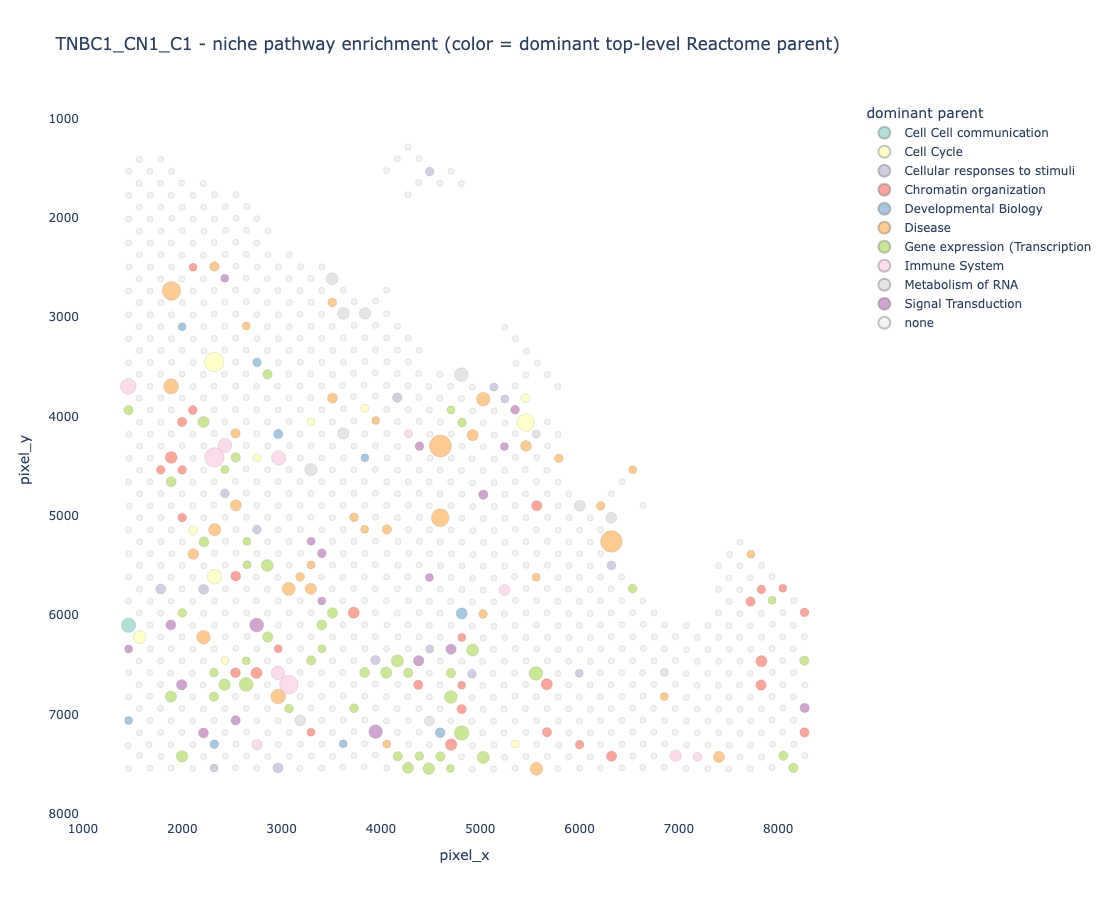

In [6]:
# plotly builder - one figure per subarray, save as HTML
def build_plotly_map(subarray, df, out_dir):
    sub = df[df['subarray'] == subarray].copy()
    if len(sub) == 0:
        print(f'  {subarray}: no niches found, skipping')
        return

    # discrete 12-color palette for top-level parents; 'none' fades to light grey
    unique_parents = [p for p in sub['dominant_parent'].unique() if p != 'none']
    colors_qual = px.colors.qualitative.Set3 + px.colors.qualitative.Pastel + px.colors.qualitative.Safe
    color_map = {p: colors_qual[i % len(colors_qual)] for i, p in enumerate(sorted(unique_parents))}
    color_map['none'] = 'rgba(200,200,200,0.3)'

    # marker size scales with sig_total, floor at 6 so zero-sig niches stay visible
    sub['marker_size'] = 6 + 2 * np.sqrt(sub['sig_total'].clip(lower=0))

    # customdata: all hover fields, aligned with hovertemplate below
    sub['mc_str'] = sub['megacluster'].apply(lambda x: f'MC{int(x)}' if pd.notna(x) else 'n/a')
    customdata = np.stack([
        sub['niche_id'].values,
        sub['spot_id'].values,
        sub['patient'].astype(str).values,
        sub['mc_str'].values,
        sub['sig_total'].astype(int).astype(str).values,
        sub['dominant_parent'].values,
        sub['top_pathways_hover'].values,
        sub['parent_breakdown'].values,
    ], axis=-1)

    # build per-parent traces so the legend is interactive (click to toggle)
    fig = go.Figure()
    for parent_name in list(sorted(unique_parents)) + ['none']:
        mask = sub['dominant_parent'].values == parent_name
        if not mask.any():
            continue
        fig.add_trace(go.Scatter(
            x=sub.loc[mask, 'pixel_x'],
            y=sub.loc[mask, 'pixel_y'],
            mode='markers',
            name=parent_name,
            marker=dict(
                color=color_map[parent_name],
                size=sub.loc[mask, 'marker_size'],
                line=dict(width=0.4, color='rgba(50,50,50,0.4)'),
            ),
            customdata=customdata[mask],
            hovertemplate=(
                '<b>%{customdata[0]}</b><br>'
                'spot_id: %{customdata[1]}<br>'
                'patient: TNBC%{customdata[2]}<br>'
                'Wang MC: %{customdata[3]}<br>'
                '<br>'
                'sig pathways total: %{customdata[4]}<br>'
                'dominant parent: <b>%{customdata[5]}</b><br>'
                '<br>'
                '<b>top 3 sig pathways:</b><br>'
                '%{customdata[6]}<br>'
                '<br>'
                '<b>sig per parent:</b><br>'
                '%{customdata[7]}'
                '<extra></extra>'
            ),
        ))

    fig.update_layout(
        title=f'{subarray} - niche pathway enrichment (color = dominant top-level Reactome parent)',
        xaxis=dict(title='pixel_x', showgrid=False, scaleanchor='y', scaleratio=1),
        yaxis=dict(title='pixel_y', autorange='reversed', showgrid=False),
        plot_bgcolor='white',
        width=1100,
        height=900,
        legend=dict(title='dominant parent', itemsizing='constant'),
        hoverlabel=dict(bgcolor='white', font_size=11, align='left'),
    )

    html_path = out_dir / f'niche_pathway_map_{subarray}.html'
    fig.write_html(html_path, include_plotlyjs='cdn')
    print(f'  {subarray}: {len(sub)} niches -> {html_path.relative_to(ROOT)}')
    return fig

figs = {}
for sub in PILOT_SUBARRAYS:
    fig = build_plotly_map(sub, results_mc, OUT_DIR)
    if fig is not None:
        figs[sub] = fig

# render the first one inline so you can immediately see it in the notebook
if figs:
    list(figs.values())[0].show()

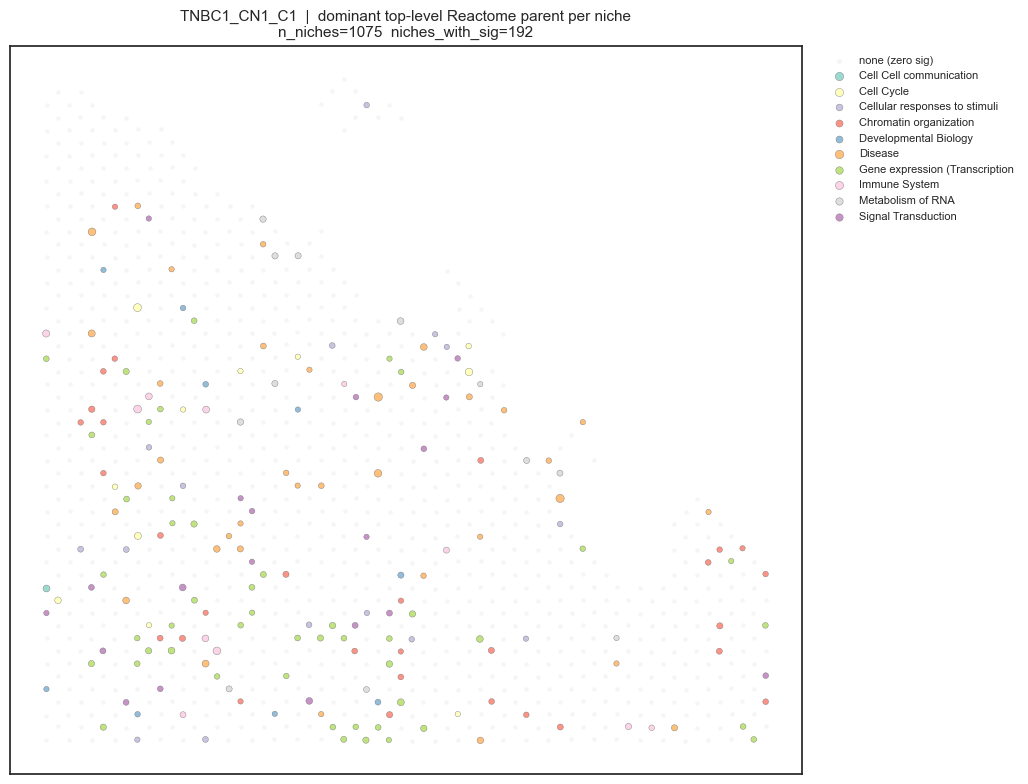

  TNBC1_CN1_C1 -> notebooks/embeddings/niche_pathway_map_TNBC1_CN1_C1.png


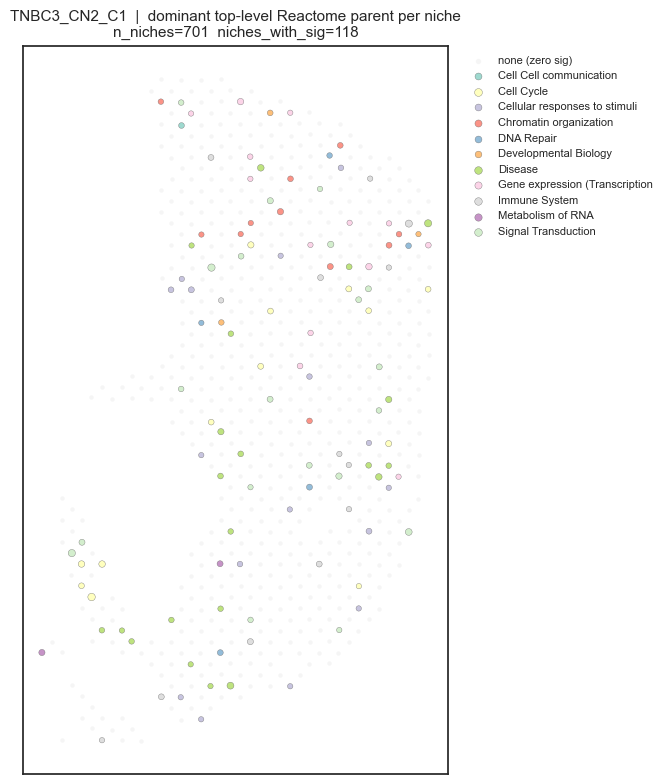

  TNBC3_CN2_C1 -> notebooks/embeddings/niche_pathway_map_TNBC3_CN2_C1.png


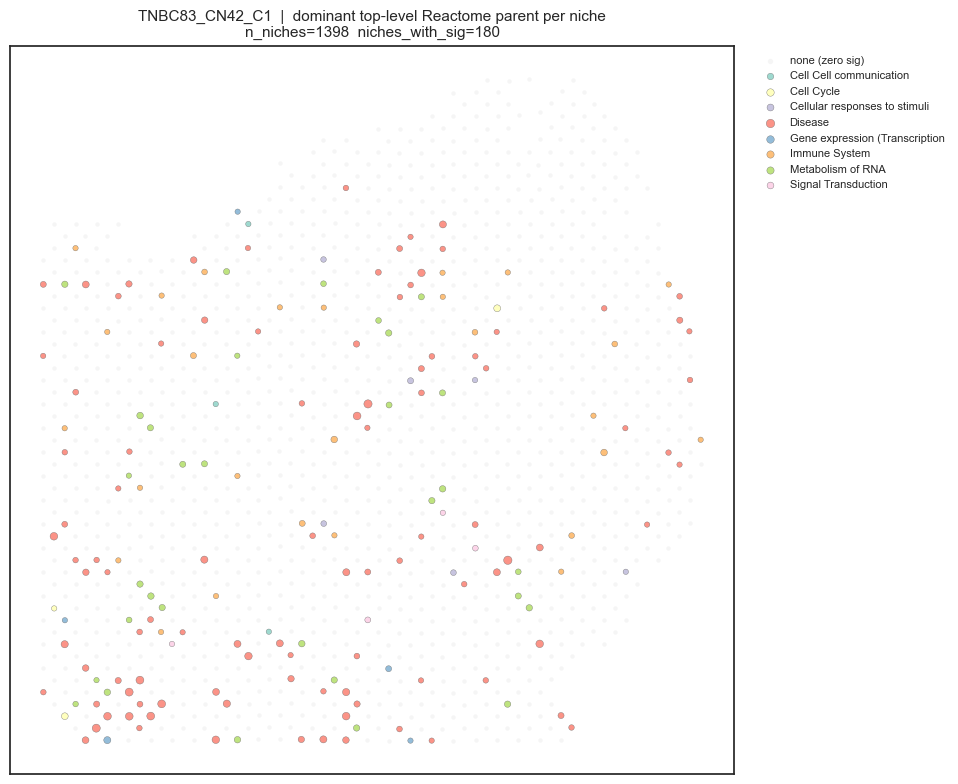

  TNBC83_CN42_C1 -> notebooks/embeddings/niche_pathway_map_TNBC83_CN42_C1.png


In [7]:
# static matplotlib version for paper/handout - one PNG per subarray
def build_matplotlib_map(subarray, df, out_dir):
    sub = df[df['subarray'] == subarray].copy()
    if len(sub) == 0:
        return

    unique_parents = sorted([p for p in sub['dominant_parent'].unique() if p != 'none'])
    palette = sns.color_palette('Set3', n_colors=max(len(unique_parents), 3))
    color_map = {p: palette[i % len(palette)] for i, p in enumerate(unique_parents)}
    color_map['none'] = (0.85, 0.85, 0.85)

    fig, ax = plt.subplots(figsize=(10, 8))

    # plot zero-sig background first (faded), then per-parent on top
    zero_mask = sub['dominant_parent'] == 'none'
    ax.scatter(sub.loc[zero_mask, 'pixel_x'], sub.loc[zero_mask, 'pixel_y'],
               c=[color_map['none']], s=10, alpha=0.25, linewidth=0, label='none (zero sig)')

    for parent in unique_parents:
        mask = sub['dominant_parent'] == parent
        sizes = 12 + 3 * np.sqrt(sub.loc[mask, 'sig_total'].clip(lower=0))
        ax.scatter(sub.loc[mask, 'pixel_x'], sub.loc[mask, 'pixel_y'],
                   c=[color_map[parent]], s=sizes, alpha=0.85, linewidth=0.3,
                   edgecolors='dimgrey', label=parent)

    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'{subarray}  |  dominant top-level Reactome parent per niche\n'
                 f'n_niches={len(sub)}  niches_with_sig={int((sub["sig_total"] > 0).sum())}',
                 fontsize=11)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, markerscale=1.2, frameon=False)
    plt.tight_layout()

    png_path = out_dir / f'niche_pathway_map_{subarray}.png'
    plt.savefig(png_path, dpi=180, bbox_inches='tight')
    plt.show()
    print(f'  {subarray} -> {png_path.relative_to(ROOT)}')

for sub in PILOT_SUBARRAYS:
    build_matplotlib_map(sub, results_mc, OUT_DIR)

## how to use

1. **Run this notebook after** `niche_pathway_analysis_full.ipynb` finishes its cell 9 -> 11 -> 12 -> 13 chain. The parquets must exist.
2. **Interactive plotly**: open any `niche_pathway_map_TNBC*.html` in a browser. Click a legend entry to toggle that parent; hover any niche to see the niche_id, Wang MC label, dominant parent, **top 3 significant Reactome pathways with FDR + OR**, and per-parent sig breakdown.
3. **Static PNG**: `niche_pathway_map_TNBC*.png` for paper/handout use. Same color coding, legend at right.
4. **To pick different pilot subarrays**: edit `PILOT_SUBARRAYS` at the top of cell 2 and re-run from cell 6 onward.
5. **No H&E image overlay in this version** - the scatter is on pixel coordinates alone. If you want to overlay on an H&E thumbnail later, the hook is `plotly.graph_objects.layout.Image` referencing a base64-encoded crop; that's a one-cell addition once you pin down the image source path in `data/inputs/byArray/{slide}/{pos}/`.

### expected visual pattern (post-QC-fix rerun)

- **IM-subtype subarray** (high MC5/MC7/MC9): dominant parent for most niches should be Immune System + Disease (IFN/cGAS-STING pathways dominate under TF-filtered Reactome).
- **Stromal / MSL subarray** (high MC13/MC14): dominant parent should shift toward Extracellular matrix organization + Signal Transduction (TGF-beta, PDGF).
- **LAR subarray** (high MC8): dominant parent should be Signal Transduction + Gene Expression (hormone receptor signaling, AR transcriptional programs).
- **Near-tissue-edge niches**: zero-sig (greyed out) after the pending `MIN_NICHE_UMI = 1000` QC fix.